In [1]:
import torch
import torch.nn as nn
import torch.functional as F
from dataclasses import dataclass

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(device)

cuda


In [98]:
# hyperparams
@dataclass
class autoencConfig:
    latent_channels: int = 4

class AutoEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.encode = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),   # 32x512x384
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 64x256x192
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 128x128x96
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),# 256x64x48
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, stride=2, padding=1),# 512x32x24
            nn.ReLU(),
        )

        # 1x1 Conv acts as a spatial bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, config.latent_channels, kernel_size=1),
            nn.GroupNorm(4, config.latent_channels),
            nn.ReLU()
        )

        # Expand back to feature channels
        self.expand = nn.Sequential(
            nn.Conv2d(config.latent_channels, 512, kernel_size=1),
            nn.ReLU()
        )

        # Decoder: mirror the encoder with ConvTranspose2d layers
        self.decode = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1),  # 256x64x48
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 128x128x96
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 64x256x192
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 32x512x384
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),      # 1x1024x768
        )

    def forward(self, x, targets=None):
        x = self.encode(x)
        x = self.bottleneck(x)
        x = self.expand(x)
        x = self.decode(x)

        if targets is None:
            loss = None
        else:
            x = torch.sigmoid(x)
            loss = nn.MSELoss()(x, targets)
        return x, loss


In [96]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

img = Image.open("target.png").convert("L")
arr = np.array(img, dtype=np.float32) / 255.0  # Normalize to [0, 1]

tensor = torch.from_numpy(arr)
tensor = tensor.reshape((1, 1, 1024, 768))
print(tensor.shape)

torch.Size([1, 1, 1024, 768])


In [105]:
model = AutoEncoder(autoencConfig())
model.to(device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
print(sum(p.numel() for p in model.parameters()))

5577677


0.018169229850172997
torch.Size([1, 1, 1024, 768])


(np.float64(-0.5), np.float64(767.5), np.float64(1023.5), np.float64(-0.5))

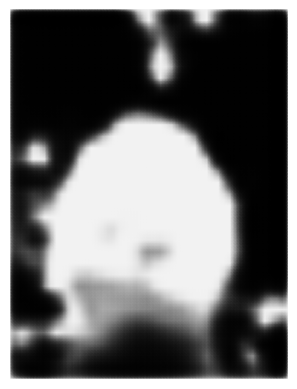

In [110]:
for _ in range(10):
    Xb = tensor.to(device=device)
    output, loss = model(Xb, Xb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    
print(loss.item())
print(output.shape)
arr = output[0].cpu().detach().reshape(1024, 768).numpy()

img = Image.fromarray((arr * 255).clip(0, 255).astype(np.uint8), mode="L")
# img.save("reconstructed.png")

plt.imshow(arr, cmap="gray")
plt.axis("off")